# Deterministic Munich Radiomap

This notebook loads the Sionna RT Munich Mitsuba scene through `witwin.channel.core.scene.Scene.load_mitsuba(...)` and runs the standalone deterministic radio-map solver on the same transmitter, frequency, and planar grid used by `monte_carlo_radiomap_bdpt_munich.ipynb`.

The default path is the protected notebook baseline: `256 x 256`, LOS plus first-order diffraction, `all_edges`, `fast_approximate + memory_safe`, and `shadow_boundary_correction=False`. On the local RTX 5080 16 GiB workstation this configuration completes under the 11 GiB gate with finite path-gain and component maps.

Second-order diffraction is available as an opt-in bounded run via `fast_approximate + memory_safe`; the metadata cells below expose state budgets, candidate backend, receiver tiling, and phase timing. Munich deterministic shadow-boundary correction is also opt-in: high-resolution runs keep it disabled by default, while the shadow-boundary correction probe uses the candidate-pruned backend and reports candidate statistics.


In [1]:
from pathlib import Path
import importlib
import subprocess
import sys
import time

import drjit as dr
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith("witwin."):
        sys.modules.pop(module_name, None)

from witwin.channel.core.scene import ReceiverGrid, Scene, SionnaAdaptor, Transmitter
from witwin.channel.core.scene.edge_policy import EdgePolicy
from witwin.channel.deterministic import Config, Tuning, native_extension_available, solve
from witwin.channel.deterministic.config import resolve_solver_controls


def gpu_memory_mib():
    try:
        output = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,memory.used",
                "--format=csv,noheader,nounits",
            ],
            text=True,
        ).strip()
    except Exception as exc:
        return {"available": False, "error": str(exc)}
    name, total, used = [part.strip() for part in output.split(",", 2)]
    return {"available": True, "name": name, "total_mib": int(total), "used_mib": int(used)}


display({
    "repo_root": repo_root_str,
    "native_extension_available": native_extension_available(),
    "gpu": gpu_memory_mib(),
})


jitc_llvm_init(): LLVM API initialization failed ..


{'repo_root': 'E:\\Code\\witwin-platform\\channel',
 'native_extension_available': True,
 'gpu': {'available': True,
  'name': 'NVIDIA GeForce RTX 5080',
  'total_mib': 16303,
  'used_mib': 3736}}

## Scene and Deterministic Configuration

In [2]:
def _default_munich_xml(root):
    return root / "reference" / "sionna-rt-reference-2.0.1" / "src" / "sionna" / "rt" / "scenes" / "munich" / "munich.xml"


def _git_common_repo_root():
    try:
        output = subprocess.check_output(
            ["git", "rev-parse", "--git-common-dir"],
            text=True,
            cwd=str(repo_root),
        ).strip()
    except Exception:
        return None
    common_dir = Path(output)
    if not common_dir.is_absolute():
        common_dir = (repo_root / common_dir).resolve()
    if common_dir.name == ".git" and (common_dir.parent / "witwin").exists():
        return common_dir.parent
    return None


def resolve_munich_xml():
    candidates = [_default_munich_xml(repo_root)]
    common_root = _git_common_repo_root()
    if common_root is not None and common_root != repo_root:
        candidates.append(_default_munich_xml(common_root))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def sionna_source_root_from_xml(munich_xml):
    for parent in munich_xml.parents:
        if parent.name == "src" and (parent / "sionna" / "rt").exists():
            return parent
    return None


MUNICH_XML = resolve_munich_xml()
SIONNA_SOURCE_ROOT = sionna_source_root_from_xml(MUNICH_XML)
FREQUENCY_HZ = 3.5e9
TX_POS = (8.5, 21.0, 27.0)
PLANE_Z = 1.5
BOUNDS = ((-120.0, 120.0), (-120.0, 140.0))
GRID_SHAPE = (256, 256)
REFLECTION_N_RAYS = 1
REFLECTION_MAX_BOUNCES = 0
REFLECTION_COEF = 0.8
MAX_DIFFRACTIONS = 1
SHADOW_BOUNDARY_CORRECTION = False
SCENE_DEVICE = "cuda"
WITWIN_EDGE_SELECTION_MODE = "all_edges"
WITWIN_EDGE_DIFFRACTION = True
WITWIN_BOUNDARY_EDGE_POLICY = "half_plane"
RUN_TX_PLACEMENT_CHECK = True
RUN_SECOND_ORDER = False
RUN_SHADOW_BOUNDARY_CORRECTION_PROBE = False
SHADOW_BOUNDARY_BACKEND = "auto"
SHADOW_BOUNDARY_TILE_SHAPE = (8, 8)
SHADOW_BOUNDARY_BAND_WIDTH_WAVELENGTHS = 3.0
SHADOW_BOUNDARY_MAX_CANDIDATE_FACTOR = 96.0
RUN_SIONNA_COMPARISON = False
SIONNA_SAMPLE_BUDGET = 1_000_000
SIONNA_MAX_DEPTH = 1


def make_deterministic_config(
    *,
    num_samples=REFLECTION_N_RAYS,
    max_bounces=REFLECTION_MAX_BOUNCES,
    max_diffraction_order=MAX_DIFFRACTIONS,
    shadow_boundary_correction=SHADOW_BOUNDARY_CORRECTION,
    solver_mode="fast_approximate",
    memory_profile="memory_safe",
    shadow_boundary_backend=SHADOW_BOUNDARY_BACKEND,
):
    return Config(
        num_samples=int(num_samples),
        max_bounces=int(max_bounces),
        max_diffraction_order=int(max_diffraction_order),
        shadow_boundary_correction=bool(shadow_boundary_correction),
        edge_policy=EdgePolicy(
            edge_selection_mode=WITWIN_EDGE_SELECTION_MODE,
            edge_diffraction=WITWIN_EDGE_DIFFRACTION,
            boundary_edge_policy=WITWIN_BOUNDARY_EDGE_POLICY,
        ),
        tuning=Tuning(
            enable_rd_diffraction=int(max_diffraction_order) > 0,
            solver_mode=solver_mode,
            memory_profile=memory_profile,
            shadow_boundary_backend=shadow_boundary_backend,
            shadow_boundary_tile_shape=SHADOW_BOUNDARY_TILE_SHAPE,
            shadow_boundary_band_width_wavelengths=SHADOW_BOUNDARY_BAND_WIDTH_WAVELENGTHS,
            shadow_boundary_max_candidate_factor=SHADOW_BOUNDARY_MAX_CANDIDATE_FACTOR,
            diffraction_execution={"accumulate_primal": "rayd_exact_coherent"},
        ),
    )


def path_gain_db(values, floor=1.0e-20):
    return 10.0 * np.log10(np.maximum(np.asarray(values, dtype=np.float64), float(floor)))


def map2d(values):
    array = np.asarray(values)
    if array.ndim == 3 and array.shape[0] == 1:
        return array[0]
    return array


def grid_extent(bounds):
    return (float(bounds[0][0]), float(bounds[0][1]), float(bounds[1][0]), float(bounds[1][1]))


def summarize_power_map(values):
    array = np.asarray(values, dtype=np.float64)
    db_values = path_gain_db(array, floor=1.0e-16)
    return {
        "sum": float(np.sum(array, dtype=np.float64)),
        "max": float(np.max(array)),
        "nonzero_cells": int(np.count_nonzero(array > 0.0)),
        "cells_above_-90_db": int(np.count_nonzero(db_values > -90.0)),
        "cells_above_-120_db": int(np.count_nonzero(db_values > -120.0)),
        "finite": bool(np.isfinite(array).all()),
    }


config = make_deterministic_config()
scene = Scene.load_mitsuba(
    MUNICH_XML,
    device=SCENE_DEVICE,
    merge_shapes=True,
    frequency=FREQUENCY_HZ,
    source_root=SIONNA_SOURCE_ROOT,
)
scene.add(Transmitter("tx", TX_POS))
grid = ReceiverGrid("rm", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=GRID_SHAPE)
scene.add(grid)

display({
    "scene_path": str(MUNICH_XML),
    "sionna_source_root": None if SIONNA_SOURCE_ROOT is None else str(SIONNA_SOURCE_ROOT),
    "scene_device": scene.device,
    "structures": len(scene.structures),
    "triangles": None if scene.tri_data is None else int(scene.tri_data["n_triangles"]),
    "diffraction_edges": scene.n_diffraction_edges,
    "grid_shape": GRID_SHAPE,
    "bounds": BOUNDS,
    "tx_pos": TX_POS,
    "frequency_hz": FREQUENCY_HZ,
    "num_samples": config.num_samples,
    "max_bounces": config.max_bounces,
    "max_diffraction_order": config.max_diffraction_order,
    "shadow_boundary_correction": config.shadow_boundary_correction,
    "solver_controls": resolve_solver_controls(config, execution_intent="coherent"),
    "witwin_edge_selection_mode": config.edge_policy.edge_selection_mode,
    "witwin_edge_diffraction": config.edge_policy.edge_diffraction,
    "witwin_boundary_edge_policy": config.edge_policy.boundary_edge_policy,
    "gpu_after_scene_load": gpu_memory_mib(),
    "mitsuba_metadata": scene.metadata.get("mitsuba"),
})


{'scene_path': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src\\sionna\\rt\\scenes\\munich\\munich.xml',
 'sionna_source_root': 'E:\\Code\\witwin-platform\\channel\\reference\\sionna-rt-reference-2.0.1\\src',
 'scene_device': 'cuda',
 'structures': 11,
 'triangles': 38936,
 'diffraction_edges': 51650,
 'grid_shape': (256, 256),
 'bounds': ((-120.0, 120.0), (-120.0, 140.0)),
 'tx_pos': (8.5, 21.0, 27.0),
 'frequency_hz': 3500000000.0,
 'num_samples': 1,
 'max_bounces': 0,
 'max_diffraction_order': 1,
 'shadow_boundary_correction': False,
 'solver_controls': {'selected': 'fast_approximate',
  'requested': {'reflection_n_rays': 1,
   'reflection_max_bounces': 0,
   'max_diffractions': 1,
   'diffraction_state_budget': None,
   'inserted_reflection_state_budget': None,
   'max_inserted_reflections_per_path': None,
   'memory_profile': 'memory_safe'},
  'effective': {'reflection_n_rays': 1,
   'reflection_max_bounces': 0,
   'max_diffractions': 1,
   'diffract

## TX Placement Check

The transmitter coordinate is the canonical Sionna Munich tutorial coordinate used by the Monte Carlo BDPT notebook. Its XY footprint overlaps the Neues Rathaus building in top-down views; this optional check verifies the 3-D rooftop placement by ray-testing around the point.

In [3]:
def _scalar_value(value):
    array = np.asarray(value)
    return float(array.reshape(-1)[0])


def _point3_values(value):
    return [_scalar_value(value[index]) for index in range(3)]


def tx_placement_check():
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    tx_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=False)
    bbox_hits = []
    for object_name, scene_object in tx_scene.objects.items():
        bbox = scene_object.mi_mesh.bbox()
        bbox_min = [float(value) for value in bbox.min]
        bbox_max = [float(value) for value in bbox.max]
        inside_bbox = (
            bbox_min[0] <= TX_POS[0] <= bbox_max[0]
            and bbox_min[1] <= TX_POS[1] <= bbox_max[1]
            and bbox_min[2] <= TX_POS[2] <= bbox_max[2]
        )
        if inside_bbox:
            bbox_hits.append({"object": str(object_name), "bbox_min": bbox_min, "bbox_max": bbox_max})

    ray_hits = {}
    for name, direction in {
        "+z": (0.0, 0.0, 1.0),
        "-z": (0.0, 0.0, -1.0),
        "+x": (1.0, 0.0, 0.0),
        "-x": (-1.0, 0.0, 0.0),
        "+y": (0.0, 1.0, 0.0),
        "-y": (0.0, -1.0, 0.0),
    }.items():
        ray = mi.Ray3f(mi.Point3f(*TX_POS), mi.Vector3f(*direction))
        si = tx_scene.mi_scene.ray_intersect(ray)
        valid = bool(np.asarray(si.is_valid()).reshape(-1)[0])
        ray_hits[name] = None if not valid else {
            "distance_m": _scalar_value(si.t),
            "point": _point3_values(si.p),
        }

    clearance_below = None if ray_hits["-z"] is None else ray_hits["-z"]["distance_m"]
    return {
        "tx_pos": tuple(float(value) for value in TX_POS),
        "bbox_containing_tx": bbox_hits,
        "ray_hits": ray_hits,
        "roof_clearance_below_m": clearance_below,
        "placement_interpretation": (
            "Open above and about 1 m above a building surface below; this is a rooftop transmitter placement."
            if ray_hits["+z"] is None and clearance_below is not None and clearance_below <= 2.0
            else "Review the ray hits before using this transmitter position."
        ),
    }


if RUN_TX_PLACEMENT_CHECK:
    display(tx_placement_check())
else:
    display({"tx_placement_check": "skipped"})


{'tx_pos': (8.5, 21.0, 27.0),
 'bbox_containing_tx': [{'object': 'Neues_Rathaus-itu_marble',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 85.0]},
  {'object': 'Neues_Rathaus-itu_metal',
   'bbox_min': [-57.44551467895508, -108.90657043457031, 0.0],
   'bbox_max': [79.86839294433594, 56.970558166503906, 63.0]}],
 'ray_hits': {'+z': None,
  '-z': {'distance_m': 1.0, 'point': [8.500000953674316, 21.0, 26.0]},
  '+x': None,
  '-x': {'distance_m': 395.5854797363281,
   'point': [-387.08544921875, 21.0, 27.0]},
  '+y': None,
  '-y': {'distance_m': 184.3910675048828,
   'point': [8.5, -163.39108276367188, 27.0]}},
 'roof_clearance_below_m': 1.0,
 'placement_interpretation': 'Open above and about 1 m above a building surface below; this is a rooftop transmitter placement.'}

## Run Deterministic Solver

In [4]:
if not native_extension_available():
    raise RuntimeError("The deterministic native extension is required for this Munich workload.")

start = time.perf_counter()
result = solve(
    scene=scene,
    transmitter="tx",
    receiver="rm",
    config=config,
)
dr.sync_thread()
solve_seconds = time.perf_counter() - start

path_gain = np.asarray(result.path_gain, dtype=np.float32)
components = {
    "los": np.asarray(result.components["los"], dtype=np.float32),
    "reflection": np.asarray(result.components["reflection"], dtype=np.float32),
    "diffraction": np.asarray(result.components["diffraction"], dtype=np.float32),
    "path_gain": path_gain,
}
component_summary = {name: summarize_power_map(values) for name, values in components.items()}
metadata = dict(result.metadata)
performance_timing = dict(metadata.get("performance_timing", {}))
diffraction_metadata = dict(metadata.get("diffraction", {}))

display({
    "solve_seconds": float(solve_seconds),
    "solver_reported_total_seconds": performance_timing.get("total_solve_seconds"),
    "path_gain_shape": path_gain.shape,
    "path_gain_min": float(np.nanmin(path_gain)),
    "path_gain_max": float(np.nanmax(path_gain)),
    "component_summary": component_summary,
    "phase_timing": performance_timing,
    "diffraction_state_count_total": diffraction_metadata.get("state_count_total"),
    "receiver_tiling_enabled": diffraction_metadata.get("receiver_tiling_enabled"),
    "receiver_tile_count": diffraction_metadata.get("receiver_tile_count"),
    "shadow_boundary_correction": metadata.get("shadow_boundary_correction"),
    "gpu_after_solve": gpu_memory_mib(),
})


{'solve_seconds': 1.0424299000005703,
 'solver_reported_total_seconds': 1.0422264999942854,
 'path_gain_shape': (1, 256, 256),
 'path_gain_min': 0.0,
 'path_gain_max': 5.4353982648081e-08,
 'component_summary': {'los': {'sum': 0.00013457544406914046,
   'max': 5.799828883823466e-08,
   'nonzero_cells': 13691,
   'cells_above_-90_db': 13691,
   'cells_above_-120_db': 13691,
   'finite': True},
  'reflection': {'sum': 0.0,
   'max': 0.0,
   'nonzero_cells': 0,
   'cells_above_-90_db': 0,
   'cells_above_-120_db': 0,
   'finite': True},
  'diffraction': {'sum': 4.003063313780915e-06,
   'max': 1.545957850623836e-08,
   'nonzero_cells': 40551,
   'cells_above_-90_db': 524,
   'cells_above_-120_db': 27488,
   'finite': True},
  'path_gain': {'sum': 0.00013799148966443892,
   'max': 5.4353982648081e-08,
   'nonzero_cells': 40551,
   'cells_above_-90_db': 14151,
   'cells_above_-120_db': 27494,
   'finite': True}},
 'phase_timing': {'grid_resolution_seconds': 0.01353880000533536,
  'los_trace

## Solver Metadata and Profiler Command

The deterministic result now carries phase timing, scene summary, solver controls, backend choices, diffraction state counts, builder reports, and receiver tiling metadata. The profiler command below reproduces the same high-resolution gate outside the notebook and can be changed to `--grid-size 256` or `--max-diffractions 2 --solver-mode fast_approximate --memory-profile memory_safe` for scaling probes.


In [5]:
builder_reports = list(diffraction_metadata.get("builder_reports", ()))
first_builder_report = builder_reports[0] if builder_reports else {}
profiler_cmd = [
    sys.executable,
    "-m",
    "tests.support.bin.profile_deterministic_munich",
    "--grid-size",
    str(GRID_SHAPE[0]),
    "--max-diffractions",
    str(MAX_DIFFRACTIONS),
    "--reflection-n-rays",
    str(REFLECTION_N_RAYS),
    "--reflection-max-bounces",
    str(REFLECTION_MAX_BOUNCES),
    "--edge-selection-mode",
    WITWIN_EDGE_SELECTION_MODE,
    "--assert-peak-used-mib-below",
    "11000",
    "--assert-finite",
    "--json",
]

display({
    "profiler_command": " ".join(str(part) for part in profiler_cmd),
    "scene_summary": metadata.get("scene_summary"),
    "solver_controls": metadata.get("solver_controls"),
    "runtime_backends": metadata.get("runtime_backends"),
    "diffraction_builder_report": first_builder_report,
})


{'profiler_command': 'C:\\Users\\Asixa\\miniconda3\\envs\\witwin2\\python.exe -m tests.support.bin.profile_deterministic_munich --grid-size 256 --max-diffractions 1 --reflection-n-rays 1 --reflection-max-bounces 0 --edge-selection-mode all_edges --assert-peak-used-mib-below 11000 --assert-finite --json',
 'scene_summary': {'n_structures': 11,
  'n_triangles': 38936,
  'n_diffraction_edges': 51650,
  'edge_selection_mode': 'all_edges',
  'edge_diffraction': True,
  'boundary_edge_policy': 'half_plane',
  'device': 'cuda'},
 'solver_controls': {'selected': 'fast_approximate',
  'requested': {'reflection_n_rays': 1,
   'reflection_max_bounces': 0,
   'max_diffractions': 1,
   'diffraction_state_budget': None,
   'inserted_reflection_state_budget': None,
   'max_inserted_reflections_per_path': None,
   'memory_profile': 'memory_safe'},
  'effective': {'reflection_n_rays': 1,
   'reflection_max_bounces': 0,
   'max_diffractions': 1,
   'diffraction_state_budget': 768,
   'inserted_reflectio

## Visualize Path Gain

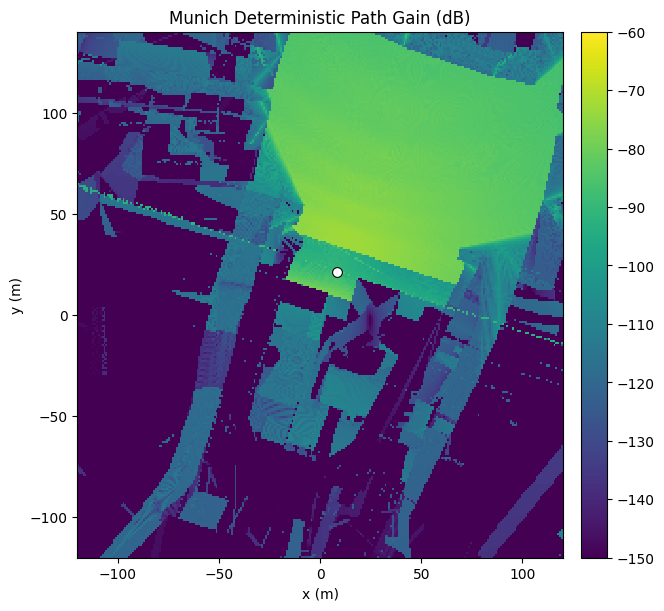

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)
image = ax.imshow(
    path_gain_db(map2d(path_gain)),
    origin="lower",
    extent=grid_extent(BOUNDS),
    cmap="viridis",
    interpolation="nearest",
    vmin=-150.0,
    vmax=-60.0,
)
ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=50, edgecolors="black", linewidths=0.8)
ax.set_title("Munich Deterministic Path Gain (dB)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Component Maps

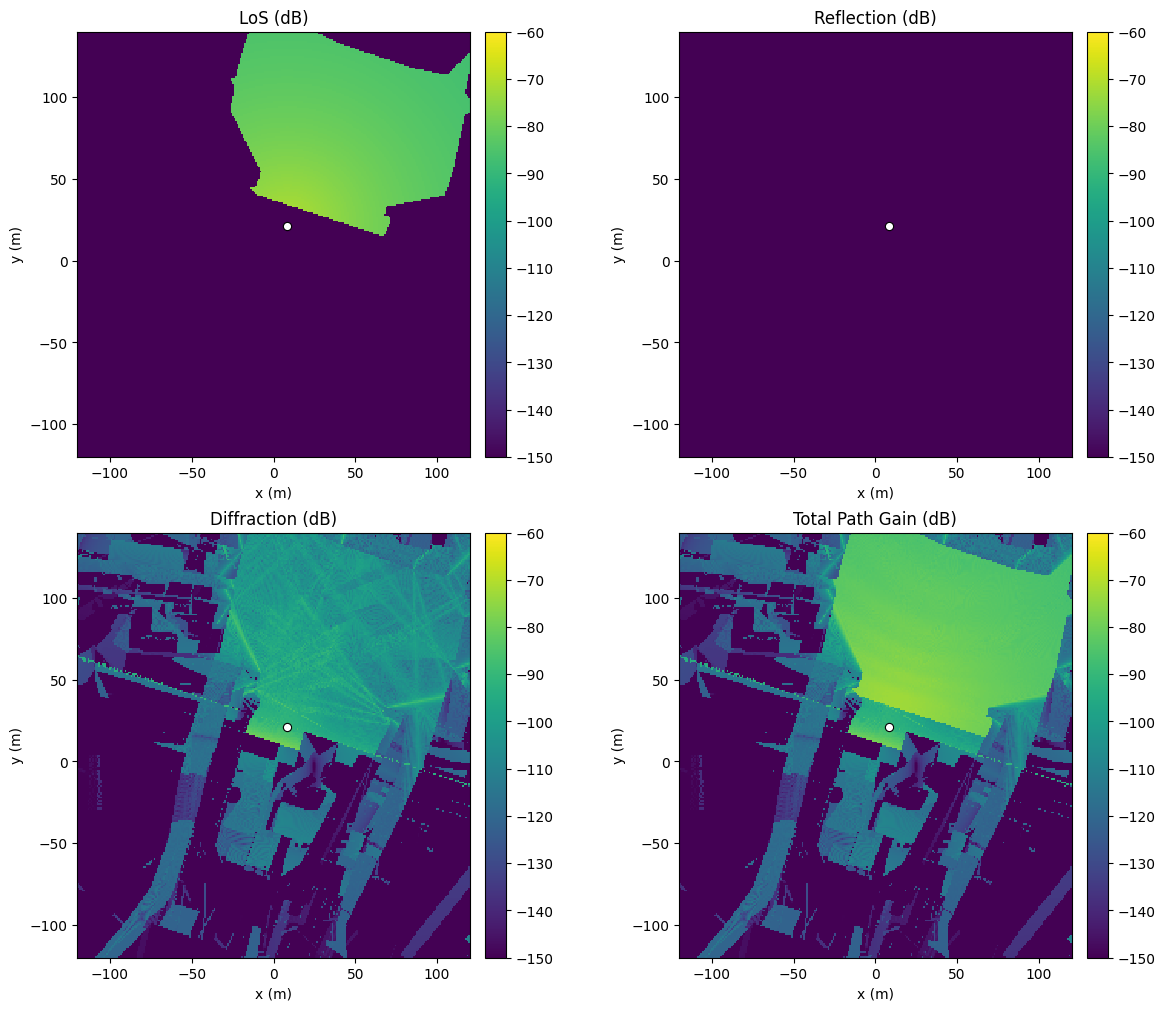

In [7]:
panel_names = ("los", "reflection", "diffraction", "path_gain")
panel_titles = {
    "los": "LoS",
    "reflection": "Reflection",
    "diffraction": "Diffraction",
    "path_gain": "Total Path Gain",
}
fig, axes = plt.subplots(2, 2, figsize=(12.0, 10.0), constrained_layout=True)
for ax, name in zip(np.asarray(axes).reshape(-1), panel_names, strict=True):
    image = ax.imshow(
        path_gain_db(map2d(components[name])),
        origin="lower",
        extent=grid_extent(BOUNDS),
        cmap="viridis",
        interpolation="nearest",
        vmin=-150.0,
        vmax=-60.0,
    )
    ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
    ax.set_title(f"{panel_titles[name]} (dB)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
plt.show()


## Optional Second-Order Probe

`max_diffractions=2` is supported as an explicit bounded workload. Use `fast_approximate + memory_safe` so the effective controls expose state budgets and the builder report shows pre-expansion pruning, candidate backend, and final state counts. This cell is opt-in because state preparation remains the dominant cost on Munich.


In [8]:
if RUN_SECOND_ORDER:
    second_order_config = make_deterministic_config(
        max_diffraction_order=2,
        solver_mode="fast_approximate",
        memory_profile="memory_safe",
    )
    second_order_grid = ReceiverGrid("rm_second_order", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=(64, 64))
    scene.add(second_order_grid)
    start = time.perf_counter()
    second_order_result = solve(
        scene=scene,
        transmitter="tx",
        receiver="rm_second_order",
        config=second_order_config,
    )
    dr.sync_thread()
    second_order_seconds = time.perf_counter() - start
    second_order_path_gain = np.asarray(second_order_result.path_gain, dtype=np.float32)
    second_metadata = dict(second_order_result.metadata)
    second_diffraction = dict(second_metadata.get("diffraction", {}))
    second_reports = list(second_diffraction.get("builder_reports", ()))
    display({
        "second_order_seconds": float(second_order_seconds),
        "second_order_shape": second_order_path_gain.shape,
        "second_order_summary": summarize_power_map(second_order_path_gain),
        "phase_timing": second_metadata.get("performance_timing"),
        "solver_controls": second_metadata.get("solver_controls"),
        "diffraction_state_count_total": second_diffraction.get("state_count_total"),
        "builder_report": second_reports[0] if second_reports else None,
        "gpu_after_second_order": gpu_memory_mib(),
    })
else:
    display({
        "second_order": "skipped",
        "reason": "Set RUN_SECOND_ORDER=True to run guarded max_diffractions=2.",
    })


{'second_order': 'skipped',
 'reason': 'Set RUN_SECOND_ORDER=True to run guarded max_diffractions=2.'}

## Optional Shadow Boundary Correction Probe

Munich-scale deterministic shadow-boundary correction now uses the candidate-pruned backend when the dense all-edge x all-cell path would exceed the safe workload limit. Keep `SHADOW_BOUNDARY_CORRECTION=False` for the default high-resolution baseline; this opt-in probe verifies the shadow-boundary backend and displays candidate counts without entering the dense replay path.


In [9]:
if RUN_SHADOW_BOUNDARY_CORRECTION_PROBE:
    shadow_boundary_correction_config = make_deterministic_config(shadow_boundary_correction=True, shadow_boundary_backend="auto")
    shadow_boundary_correction_grid = ReceiverGrid("rm_shadow_boundary", axis="z", position=PLANE_Z, bounds=BOUNDS, grid_shape=(256, 256))
    scene.add(shadow_boundary_correction_grid)
    start = time.perf_counter()
    shadow_boundary_correction_result = solve(
        scene=scene,
        transmitter="tx",
        receiver="rm_shadow_boundary",
        config=shadow_boundary_correction_config,
    )
    dr.sync_thread()
    shadow_boundary_correction_seconds = time.perf_counter() - start
    shadow_boundary_correction_metadata = dict(shadow_boundary_correction_result.metadata).get("shadow_boundary_correction", {})
    shadow_boundary_correction_stats = dict(shadow_boundary_correction_metadata.get("statistics", {}))
    display({
        "shadow_boundary_correction_probe": "completed",
        "seconds": float(shadow_boundary_correction_seconds),
        "shape": np.asarray(shadow_boundary_correction_result.path_gain).shape,
        "backend": shadow_boundary_correction_metadata.get("backend"),
        "candidate_pairs": shadow_boundary_correction_stats.get("candidate_pairs"),
        "candidate_ratio": shadow_boundary_correction_stats.get("candidate_ratio"),
        "source_visible_edges": shadow_boundary_correction_stats.get("source_visible_edges"),
        "metadata": shadow_boundary_correction_metadata,
        "gpu_after_shadow_boundary_correction_probe": gpu_memory_mib(),
    })
else:
    display({
        "shadow_boundary_correction_probe": "skipped",
        "reason": "Set RUN_SHADOW_BOUNDARY_CORRECTION_PROBE=True to run the candidate-pruned shadow-boundary correction probe.",
    })


{'shadow_boundary_correction_probe': 'skipped',
 'reason': 'Set RUN_SHADOW_BOUNDARY_CORRECTION_PROBE=True to run the candidate-pruned shadow-boundary correction probe.'}

## Optional Sionna RT Comparison

This mirrors the comparison section from the Monte Carlo BDPT Munich notebook. It is disabled by default because the deterministic support check above is the primary purpose of this notebook.

In [10]:
def sionna_radio_map_geometry():
    span_x = float(BOUNDS[0][1] - BOUNDS[0][0])
    span_y = float(BOUNDS[1][1] - BOUNDS[1][0])
    nx, ny = (int(value) for value in GRID_SHAPE)
    return {
        "center": (0.5 * (BOUNDS[0][0] + BOUNDS[0][1]), 0.5 * (BOUNDS[1][0] + BOUNDS[1][1]), PLANE_Z),
        "orientation": (0.0, 0.0, 0.0),
        "size": (span_x, span_y),
        "cell_size": (span_x / float(nx), span_y / float(ny)),
        "tensor_shape": (ny, nx),
    }


def run_sionna_radio_map(*, diffraction):
    rt = SionnaAdaptor.load_rt(prefer_local=True)
    mi = importlib.import_module("mitsuba")
    sionna_scene = rt.load_scene(str(MUNICH_XML), merge_shapes=True)
    sionna_scene.frequency = FREQUENCY_HZ
    sionna_scene.tx_array = rt.PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
    sionna_scene.add(rt.Transmitter("tx", position=mi.Point3f(*TX_POS), power_dbm=0.0))
    geometry = sionna_radio_map_geometry()
    solver = rt.RadioMapSolver()
    start = time.perf_counter()
    radio_map = solver(
        sionna_scene,
        center=mi.Point3f(*geometry["center"]),
        orientation=mi.Point3f(*geometry["orientation"]),
        size=mi.Point2f(*geometry["size"]),
        cell_size=mi.Point2f(*geometry["cell_size"]),
        samples_per_tx=int(SIONNA_SAMPLE_BUDGET),
        max_depth=int(SIONNA_MAX_DEPTH),
        los=True,
        specular_reflection=True,
        refraction=False,
        diffraction=bool(diffraction),
        edge_diffraction=bool(diffraction),
        seed=11,
    )
    return {
        "path_gain": np.asarray(radio_map.path_gain, dtype=np.float64)[0],
        "cell_centers": np.asarray(radio_map.cell_centers, dtype=np.float64),
        "seconds": float(time.perf_counter() - start),
        "geometry": geometry,
    }


if RUN_SIONNA_COMPARISON:
    sionna_with_diff = run_sionna_radio_map(diffraction=True)
    sionna_total = sionna_with_diff["path_gain"]
    witwin_total = map2d(path_gain)
    if tuple(witwin_total.shape) != tuple(sionna_total.shape):
        raise RuntimeError(f"Witwin/Sionna radio-map shape mismatch: {witwin_total.shape} vs {sionna_total.shape}")
    delta_db = path_gain_db(witwin_total) - path_gain_db(sionna_total)
    finite_delta = delta_db[np.isfinite(delta_db)]
    display({
        "sionna_samples_per_tx": int(SIONNA_SAMPLE_BUDGET),
        "sionna_max_depth": int(SIONNA_MAX_DEPTH),
        "sionna_with_diff_seconds": sionna_with_diff["seconds"],
        "witwin_sum": float(np.sum(witwin_total, dtype=np.float64)),
        "sionna_sum": float(np.sum(sionna_total, dtype=np.float64)),
        "witwin_minus_sionna_db_p05_p50_p95": tuple(float(value) for value in np.percentile(finite_delta, [5.0, 50.0, 95.0])),
    })

    panels = (
        (path_gain_db(witwin_total), "Witwin deterministic total (dB)", "viridis", -150.0, -60.0),
        (path_gain_db(sionna_total), "Sionna RT total (dB)", "viridis", -150.0, -60.0),
        (delta_db, "Witwin - Sionna (dB)", "coolwarm", -30.0, 30.0),
    )
    fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0), constrained_layout=True)
    for ax, (values, title, cmap, vmin, vmax) in zip(axes, panels, strict=True):
        image = ax.imshow(values, origin="lower", extent=grid_extent(BOUNDS), cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
        ax.scatter([TX_POS[0]], [TX_POS[1]], c="white", s=35, edgecolors="black", linewidths=0.8)
        ax.set_title(title)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
    plt.show()
else:
    display({
        "sionna_comparison": "skipped",
        "reason": "Set RUN_SIONNA_COMPARISON=True to run the optional Sionna comparison.",
    })


{'sionna_comparison': 'skipped',
 'reason': 'Set RUN_SIONNA_COMPARISON=True to run the optional Sionna comparison.'}

## Resource Notes

On the local RTX 5080 16 GiB workstation, the verified deterministic Munich support envelope is:

- Scene load: 38,936 triangles and 51,631 `all_edges` diffraction edges.
- `256 x 256`, LOS plus first-order diffraction, `max_diffractions=1`, `fast_approximate + memory_safe`, `shadow_boundary_correction=False`: default notebook baseline for interactive runs.
- `256 x 256`, LOS plus first-order diffraction, `max_diffractions=1`, `shadow_boundary_correction=True`: run only as an explicit candidate-pruned probe.
- `max_diffractions=2` with `fast_approximate + memory_safe`: supported as a bounded opt-in path; metadata reports pre-expansion pruning, `rayd_edge_bvh` candidate selection, state budgets, and final state counts.
- `memory_safe` receiver-side diffraction accumulation uses receiver tiling for larger grids and reports tile count/size in result metadata.
- `shadow_boundary_correction=True`: large grids route to `shadow_boundary_backend="native_candidate"` through `auto`; small reference grids can still request `shadow_boundary_backend="dense_native"` for the exact dense statistics path.

For Munich-scale deterministic experiments, use the default first-order high-resolution path for reliable maps, use the profiler script for benchmark gates, and enable second-order or shadow-boundary correction probes only when explicitly profiling those paths.
